In [1]:
%cd ../..

/home/jj/Research/ConceptualSensitivityRegularization


### Investigating `minor_ratio` in Waterbirds module

/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


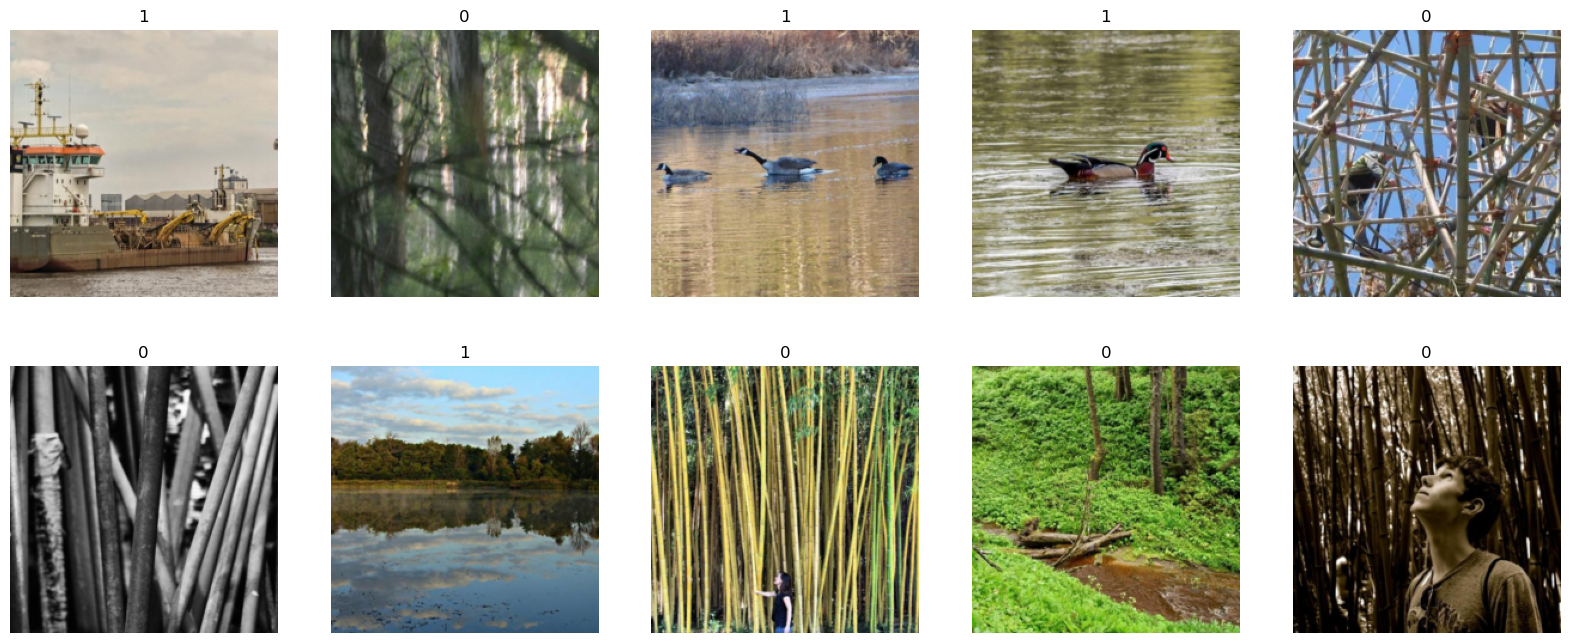

In [2]:
from csr.module.dataset.concept_dataset import ConceptDataset
import os
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms

root = '/media/disk2/Data/Places365'

transform_ = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

dataset_train = ConceptDataset(root=os.path.join(root), dataset='catdog_concepts', model_name='convnect_t', transform=transform_)


# plot some images (2*5)
for x, y, _, _ in DataLoader(dataset_train, batch_size=128, num_workers=16, shuffle=True):
    x = x[:10]
    y = y[:10]
    break

fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i, ax in enumerate(axs.flatten()):
    img = x[i].permute(1, 2, 0)
    # unnormalize image
    img = img * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
    ax.imshow(img)
    ax.set_title(f'{y[i]}')
    ax.axis('off')
plt.show()


